Importación de paquetes


In [10]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


importar data


In [11]:
df = pd.read_csv("/content/Data_PI_regresion.csv")
df.head()

,Temperatura,Horas_Operacion,Carga,Humedad,Consumo_Energia
0,29.8,7.4,76.4,87.0,28.97
1,22.9,4.3,88.8,74.9,21.85
2,21.9,10.4,87.7,65.7,37.43
3,27.4,7.8,55.7,79.0,26.32
4,30.2,6.9,42.3,62.9,26.08


Descripcion de todo los componentes

In [12]:
df.describe().round(1)

,Temperatura,Horas_Operacion,Carga,Humedad,Consumo_Energia
count,5000.0,5000.0,5000.0,5000.0,5000.0
mean,26.5,7.0,65.0,65.1,26.0
std,4.9,2.9,20.3,14.3,5.6
min,18.0,2.0,30.0,40.0,9.1
25%,22.1,4.4,47.3,52.7,21.8
50%,26.5,7.0,65.7,65.0,26.1
75%,30.7,9.4,82.5,77.5,30.3
max,35.0,12.0,100.0,90.0,42.6


Obtener nombres de las características

In [13]:
df.columns

Index(['Temperatura', 'Horas_Operacion', 'Carga', 'Humedad',
       'Consumo_Energia'],
      dtype='object')

Visualización: relaciones entre todas las variables

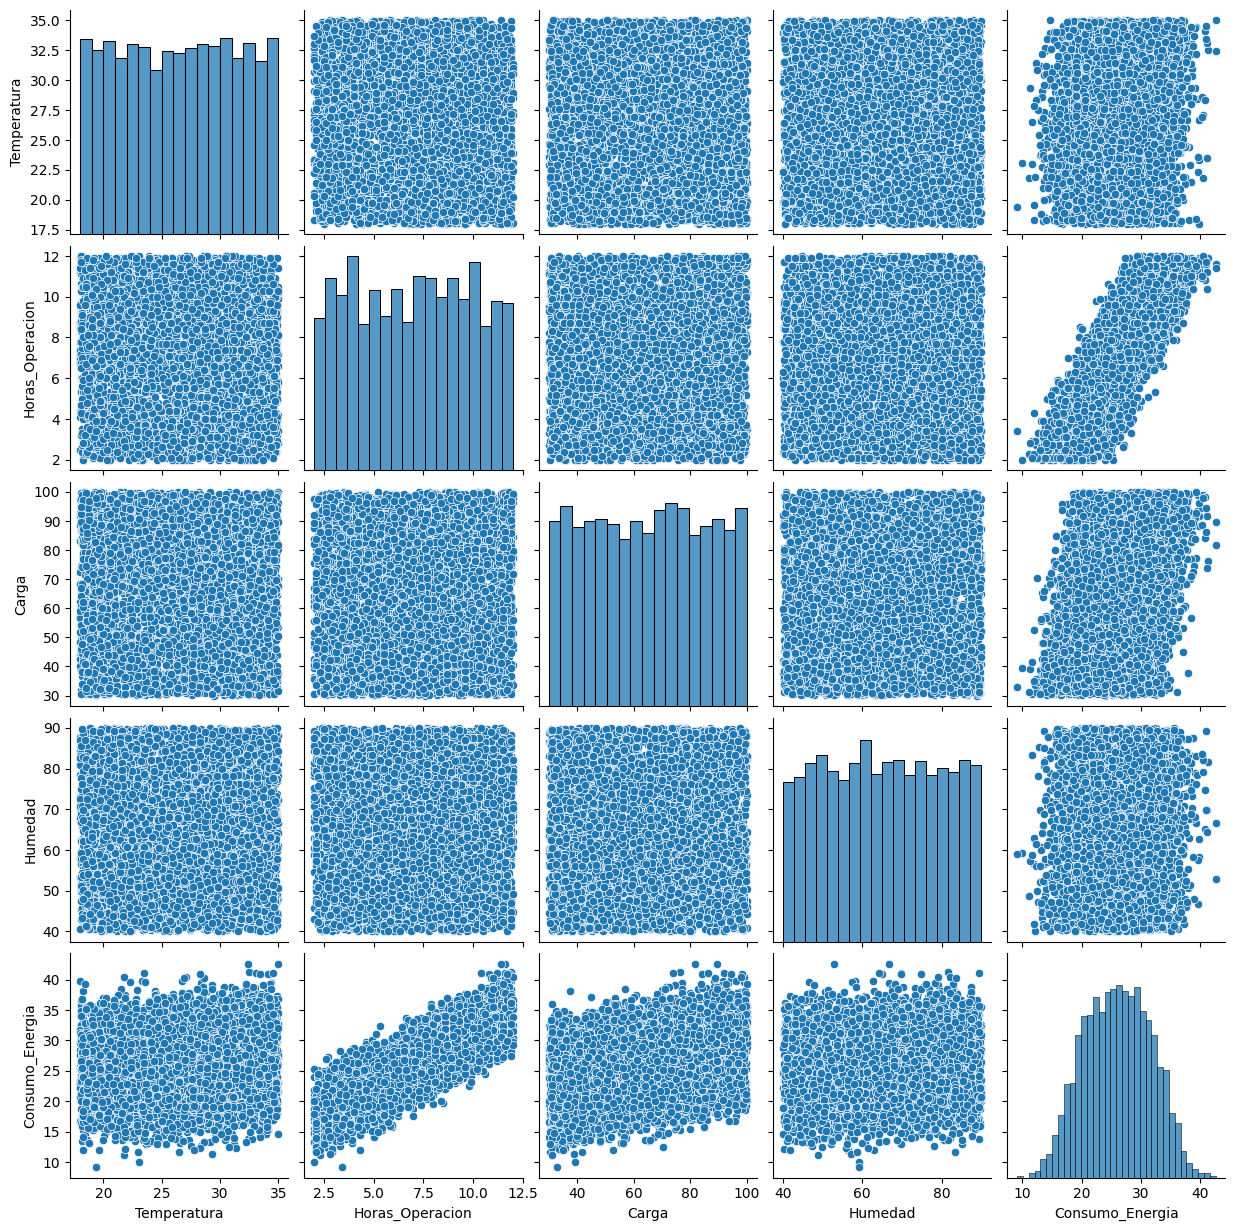

In [14]:
sns.pairplot(df)

Histograma: distribución del consumo de energía

<Axes: ylabel='Frequency'>

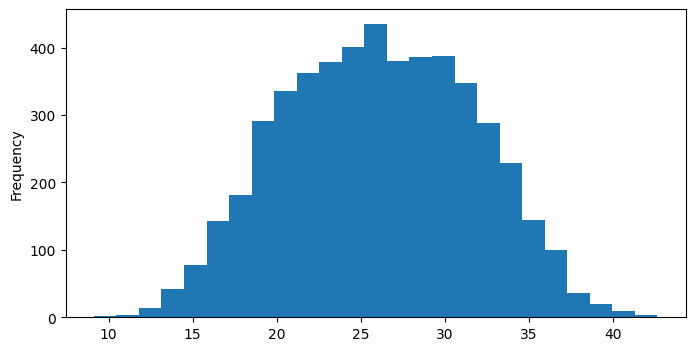

In [15]:
df['Consumo_Energia'].plot.hist(bins=25, figsize=(8, 4))

Curva de densidad del consumo de energía

<Axes: ylabel='Density'>

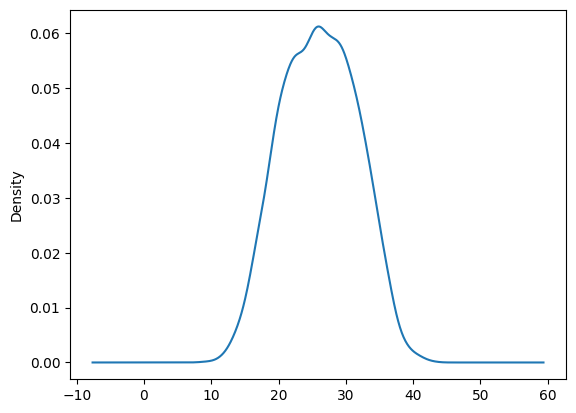

In [16]:
df['Consumo_Energia'].plot.density()


Matriz de correlación

In [17]:
numeric_df = df.select_dtypes(include=[np.number])
# Selecciona solo las columnas con valores numéricos

numeric_df.corr().round(4)
# Cálculo de la correlación

,Temperatura,Horas_Operacion,Carga,Humedad,Consumo_Energia
Temperatura,1.0000,-0.0260,0.0102,0.0166,0.0978
Horas_Operacion,-0.0260,1.0000,-0.0099,0.0060,0.8434
Carga,0.0102,-0.0099,1.0000,0.0060,0.3366
Humedad,0.0166,0.0060,0.0060,1.0000,0.0627
Consumo_Energia,0.0978,0.8434,0.3366,0.0627,1.0000


Mapa de calor de correlación

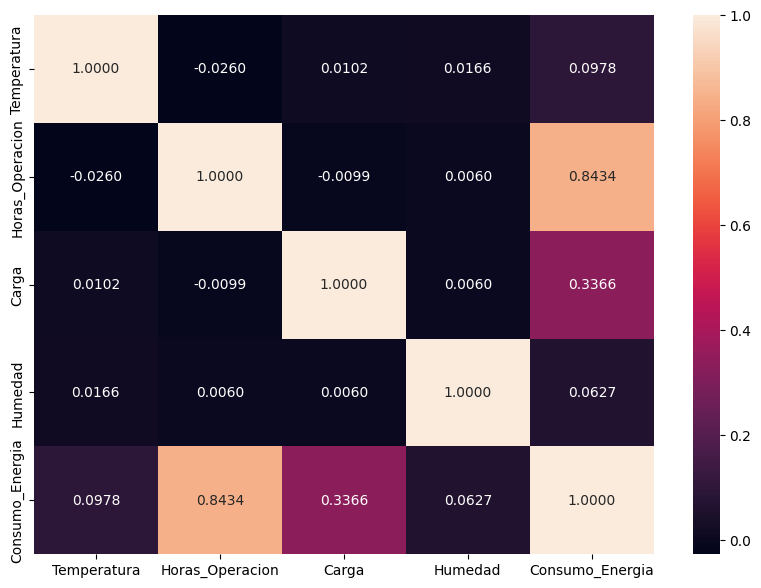

In [18]:
plt.figure(figsize=(10, 7))
# Comando para graficar el heatmap (completado):
sns.heatmap(numeric_df.corr(), annot=True, fmt='.4f')
plt.show()

Preparar conjuntos de características y variable objetivo

In [19]:
l_column = list(df.columns)          # Haciendo una lista de las columnas
len_feature = len(l_column)           # Longitud de la lista de vectores de columna
l_column

['Temperatura', 'Horas_Operacion', 'Carga', 'Humedad', 'Consumo_Energia']

Definir variables para regresión lineal

In [20]:
X = df[l_column[0 : len_feature - 1]]   # Variables independientes: las primeras 4
y = df[l_column[len_feature - 1]]       # Variable objetivo: Consumo_Energia
X.head()

,Temperatura,Horas_Operacion,Carga,Humedad
0,29.8,7.4,76.4,87.0
1,22.9,4.3,88.8,74.9
2,21.9,10.4,87.7,65.7
3,27.4,7.8,55.7,79.0
4,30.2,6.9,42.3,62.9


In [21]:
y.head()

,Consumo_Energia
0,28.97
1,21.85
2,37.43
3,26.32
4,26.08


División en conjuntos de entrenamiento y prueba

In [22]:
from sklearn.model_selection import train_test_split
# divide datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)

Importar modelo y métricas

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [24]:
lm = LinearRegression()   # Creando un objeto de Regresión Lineal 'lm'

In [25]:
lm.fit(X_train, y_train)  # Ajustar y entrenar

LinearRegression()

In [26]:
print("El término de intersección del modelo lineal:", lm.intercept_)

El término de intersección del modelo lineal: 2.741067446117448


In [27]:
print("Los coeficientes del modelo lineal:", lm.coef_)

Los coeficientes del modelo lineal: [0.13713677 1.66877804 0.09634816 0.02679108]


In [28]:
cdf = pd.DataFrame(data=lm.coef_, index=X_train.columns, columns=["Coeficientes"])
cdf

,Coeficientes
Temperatura,0.137137
Horas_Operacion,1.668778
Carga,0.096348
Humedad,0.026791


Cálculo de errores estándar y estadístico t

In [29]:
n = X_train.shape[0]           # cantidad de datos de entrenamiento
k = X_train.shape[1]           # cantidad de variables = 4
dfn = n - k                    # grados de libertad

train_pred = lm.predict(X_train)  # obtener predicciones

# calculamos el error: R²
train_error = np.square(train_pred - y_train)  # comparamos (predicción - valor real)²
sum_error = np.sum(train_error)                # suma de errores
# ¿qué tanto se equivocó el modelo?

se = [0,0,0,0]
for i in range(k):
    r = (sum_error / dfn)
    # ¿cuánto varía el valor respecto a su promedio?
    # selecciona variable: "Temperatura"
    r = r / np.sum(np.square(X_train[list(X_train.columns)[i]] - X_train[list(X_train.columns)[i]].mean()))
    se[i] = np.sqrt(r)  # cálculo del error estándar

cdf["Standard Error"] = se
cdf["t-statistic"] = cdf["Coeficientes"] / cdf["Standard Error"]
# ¿El coeficiente es grande en comparación con la incertidumbre que tiene?
# ¿está alejado de cero respecto a su error estándar?
cdf

,Coeficientes,Standard Error,t-statistic
Temperatura,0.137137,0.007557,18.147233
Horas_Operacion,1.668778,0.013138,127.020720
Carga,0.096348,0.001859,51.826973
Humedad,0.026791,0.002611,10.260097


\Gráficos de dispersión por variable vs. Consumo de Energía


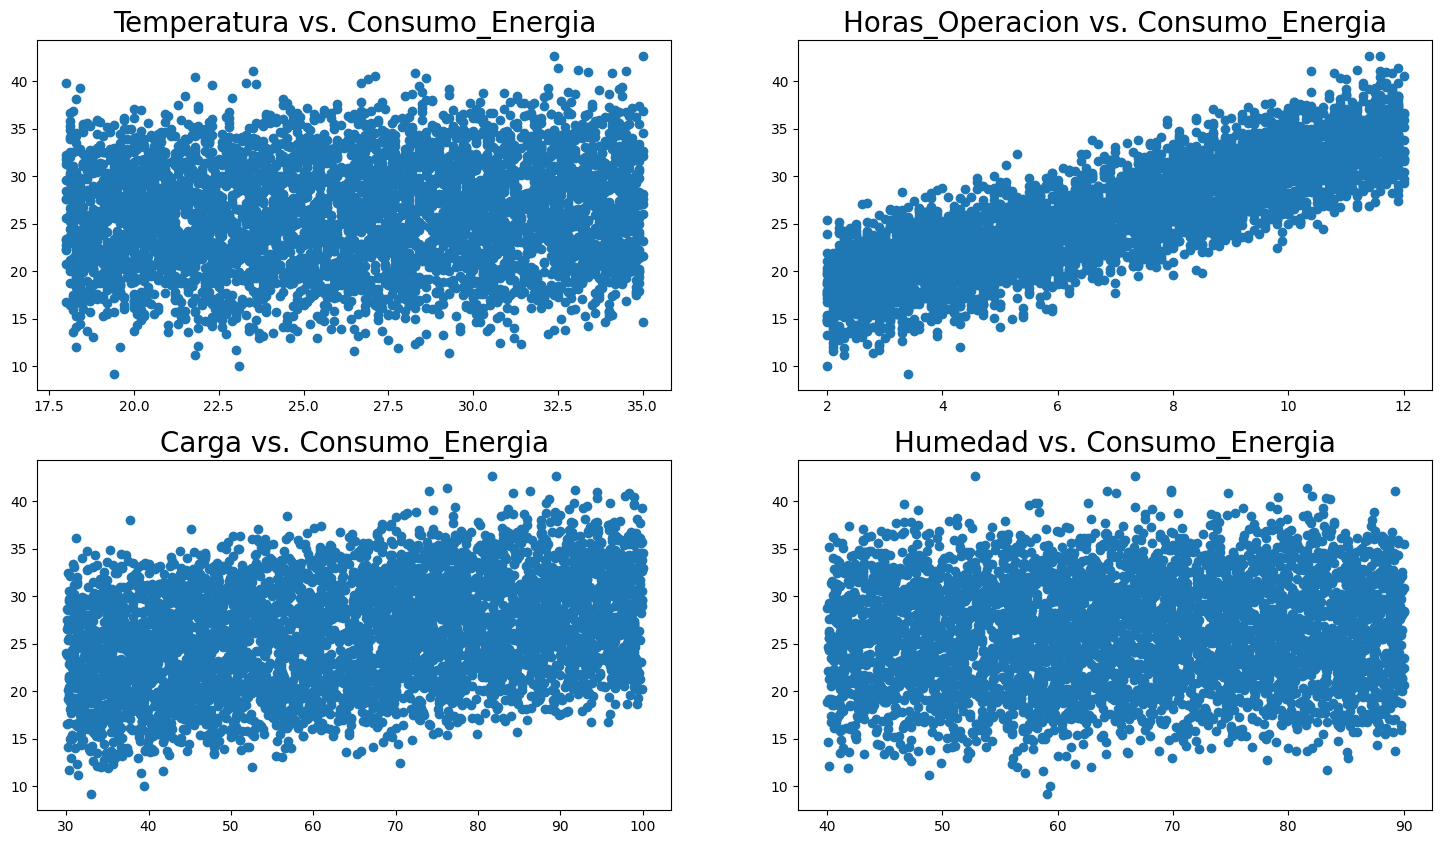

In [30]:
l = list(cdf.index)

from matplotlib import gridspec
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 2)

ax0 = plt.subplot(gs[0])
ax0.scatter(df[l[0]], df['Consumo_Energia'])
ax0.set_title(f"{l[0]} vs. Consumo_Energia", fontdict={'fontsize': 20})

ax1 = plt.subplot(gs[1])
ax1.scatter(df[l[1]], df['Consumo_Energia'])
ax1.set_title(f"{l[1]} vs. Consumo_Energia", fontdict={'fontsize': 20})

ax2 = plt.subplot(gs[2])
ax2.scatter(df[l[2]], df['Consumo_Energia'])
ax2.set_title(f"{l[2]} vs. Consumo_Energia", fontdict={'fontsize': 20})

ax3 = plt.subplot(gs[3])
ax3.scatter(df[l[3]], df['Consumo_Energia'])
ax3.set_title(f"{l[3]} vs. Consumo_Energia", fontdict={'fontsize': 20})

plt.show()

Generar predicciones

In [31]:
predictions = lm.predict(X_test)
print("Tipo del objeto predicho:", type(predictions))
print("Tamaño del objeto predicho:", predictions.shape)

Tipo del objeto predicho: <class 'numpy.ndarray'>
Tamaño del objeto predicho: (1500,)


Gráfico: Consumo real vs. Consumo predicho

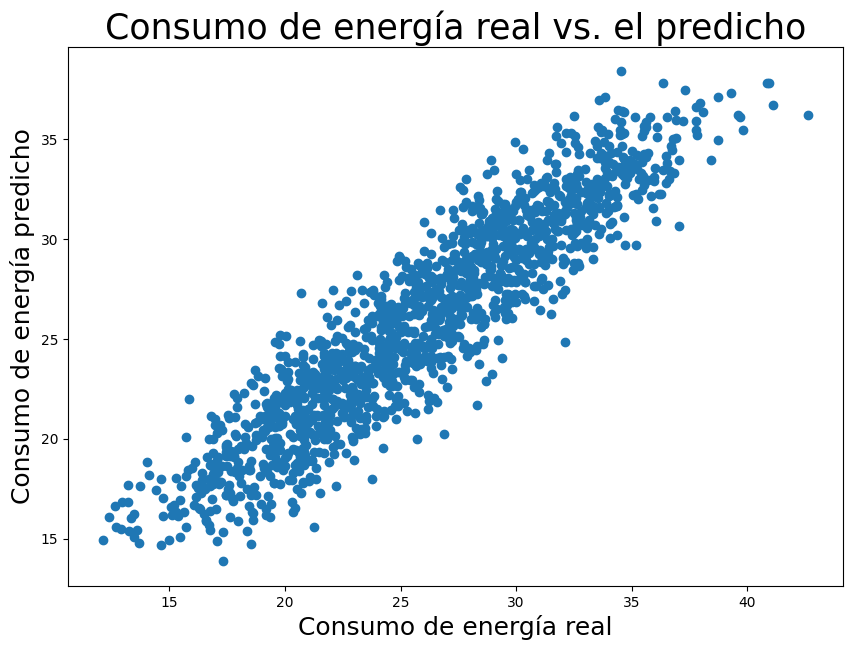

In [32]:
# Diagrama de dispersión
# Meta: Datos caen en una línea recta de 45°

plt.figure(figsize=(10, 7))
plt.title("Consumo de energía real vs. el predicho", fontsize=25)
plt.xlabel("Consumo de energía real", fontsize=18)
plt.ylabel("Consumo de energía predicho", fontsize=18)
plt.scatter(y_test, predictions)
plt.show()

Histograma de residuos para verificar normalidad

/tmp/ipykernel_1660/342321235.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test - predictions) # histplot


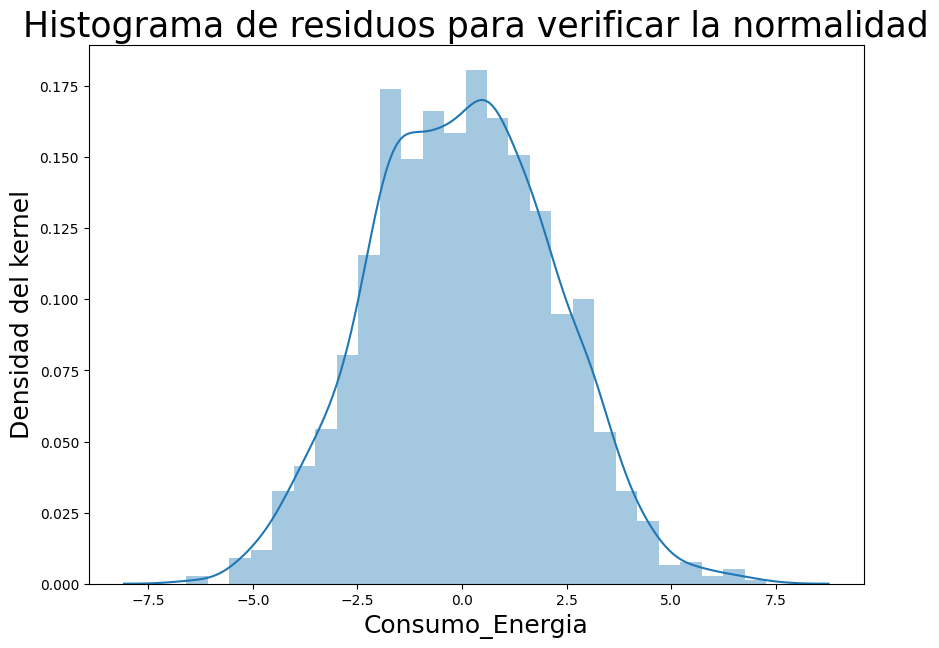

In [33]:
plt.figure(figsize=(10, 7))
plt.title("Histograma de residuos para verificar la normalidad", fontsize=25)
plt.xlabel("Residuos", fontsize=18)
plt.ylabel("Densidad del kernel", fontsize=18)

# Versión original (con advertencia de obsolescencia):
sns.distplot(y_test - predictions) # histplot

plt.show()

Gráfico de residuos vs. predicciones (Homocedasticidad)

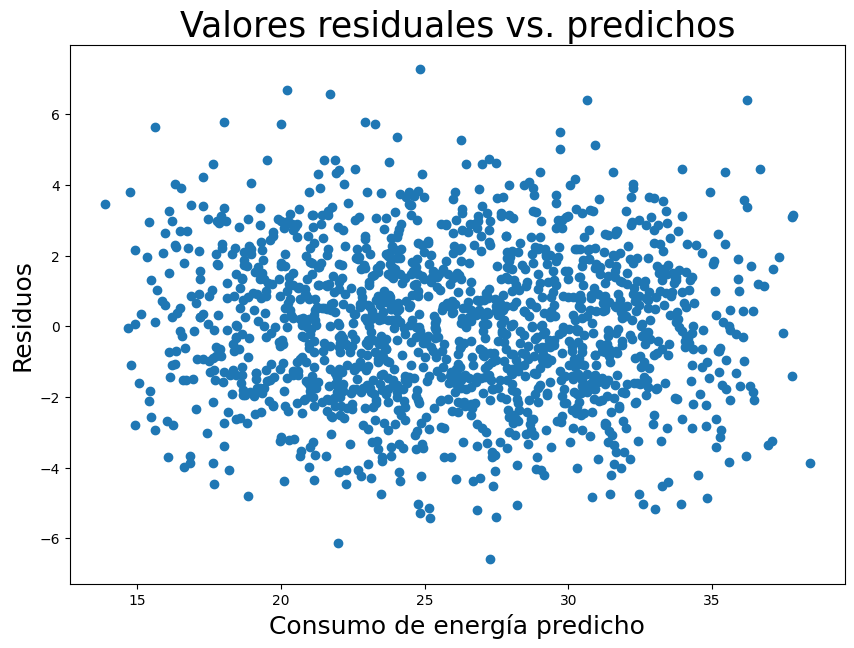

In [34]:
plt.figure(figsize=(10, 7))
plt.title("Valores residuales vs. predichos", fontsize=25)
plt.xlabel("Consumo de energía predicho", fontsize=18)
plt.ylabel("Residuos", fontsize=18)
plt.scatter(x=predictions, y=y_test - predictions)
plt.show()

Inicio: Datos sintéticos para Bosque Aleatorio

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Importar el método make_regression para generar muestras de datos artificiales
from sklearn.datasets import make_regression

n_samples = 100     # Número de muestras
n_features = 6      # Número de características
n_informative = 3   # Número de características informativas (las que realmente influyen)

X, y, coef = make_regression(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=n_informative,
    random_state=20,      # semilla aleatoria (reproducibilidad)
    shuffle=False,        # que no se mezclen las características
    noise=20,             # ruido aleatorio
    coef=True             # devuelve los coeficientes reales
)

print(coef)

[78.58638696 97.72361019 52.30606265  0.          0.          0.        ]


Crear DataFrame y mostrar datos

In [36]:
# Crear tabla con variables independientes: X1, X2, ..., X6
df1 = pd.DataFrame(
    data=X,
    columns=[f'X{i+1}' for i in range(n_features)]
)

# Crear columna con variable objetivo
df2 = pd.DataFrame(data=y, columns=['y'])

# Unir ambas tablas
df = pd.concat([df1, df2], axis=1)

# Mostrar primeras 10 filas
df.head(10)

,X1,X2,X3,X4,X5,X6,y
0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,109.512132
1,0.939469,-0.978481,0.503097,0.406414,0.323461,-0.493411,52.542242
2,-0.792017,-0.842368,-1.279503,0.245715,-0.044195,1.567633,-247.679018
3,1.051109,0.406368,-0.168646,-3.189703,1.120132,1.332778,98.678111
4,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-55.286890
5,-0.885493,-1.104579,0.932866,2.059838,-0.934938,-1.612990,-94.821349
6,0.527070,-1.551101,0.329613,-1.136527,-0.338491,0.320971,-75.940071
7,-0.602308,1.544728,0.647034,0.593217,0.438024,1.357789,139.247064
8,1.204511,1.351796,0.493437,-2.704365,-0.555186,0.001509,246.470338
9,0.857094,1.481144,-0.219661,1.503398,-1.482385,-0.856164,204.709196


Gráficos de dispersión: cada variable vs. salida

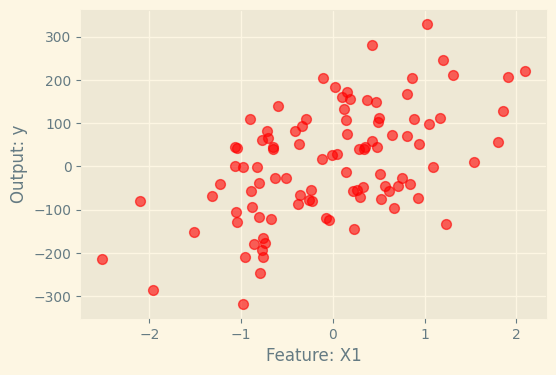

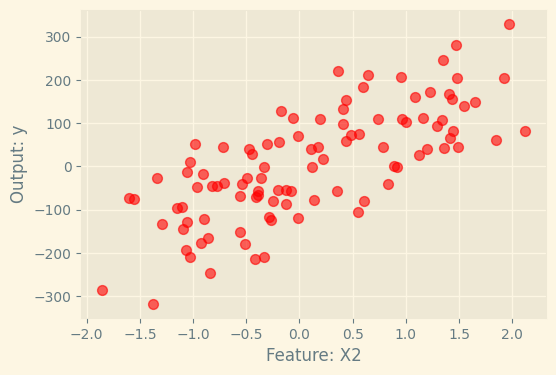

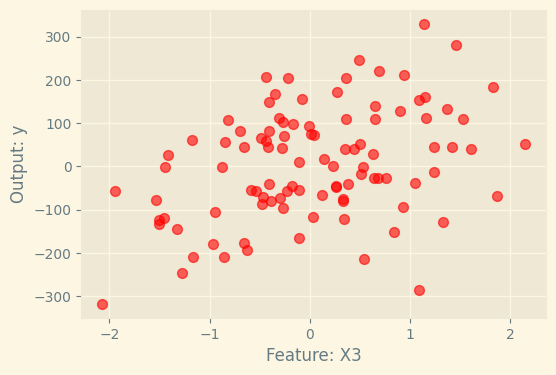

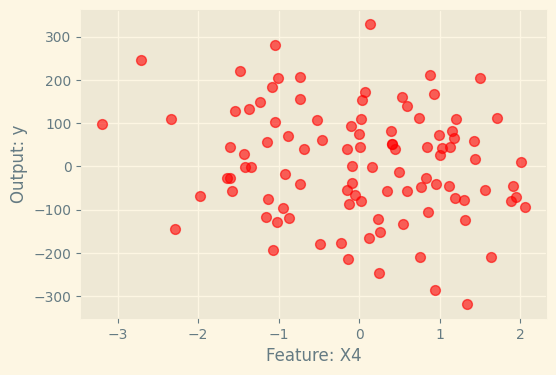

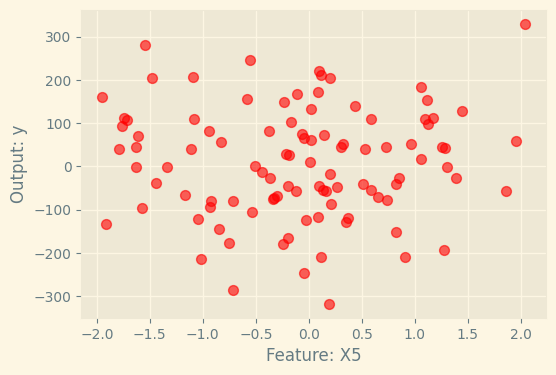

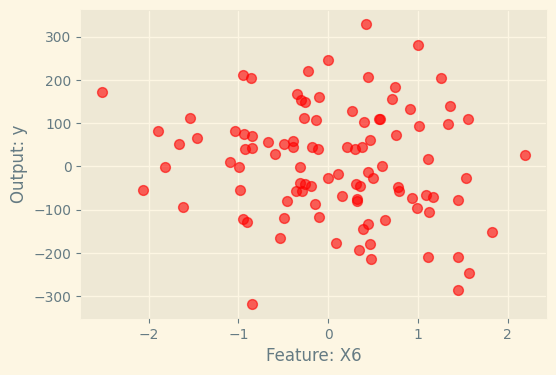

In [37]:
with plt.style.context('Solarize_Light2'):
    for i, col in enumerate(df.columns[:-1]):  # recorrer todas las variables excepto 'y'
        plt.figure(figsize=(6, 4))
        plt.grid(True)
        plt.xlabel(f'Feature: {col}', fontsize=12)
        plt.ylabel('Output: y', fontsize=12)
        plt.scatter(df[col], df['y'], c='red', s=50, alpha=0.6)
plt.show()

División entrenamiento / prueba

In [38]:
from sklearn import tree
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)

Crear y entrenar Árbol de Decisión

In [39]:
# Creación del modelo
tree_model = tree.DecisionTreeRegressor(max_depth=5, random_state=10)
# max_depth = niveles máximos de decisión

tree_model.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=5, random_state=10)

Predecir y evaluar

Mean square error (MSE): 7931.574768958281


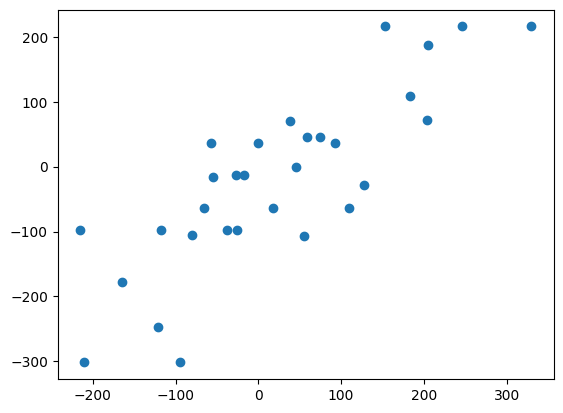

In [40]:
from sklearn import metrics

# Hacemos predicciones
test_pred = tree_model.predict(X_test)

plt.scatter(x=y_test, y=test_pred)  # real vs. predicho

print("Mean square error (MSE):", metrics.mean_squared_error(y_test, test_pred))
# Error cuadrático medio

Importancia de las características

Importancia relativa de las características:  [0.26900246 0.53730467 0.11075698 0.03758107 0.01219288 0.03316193]


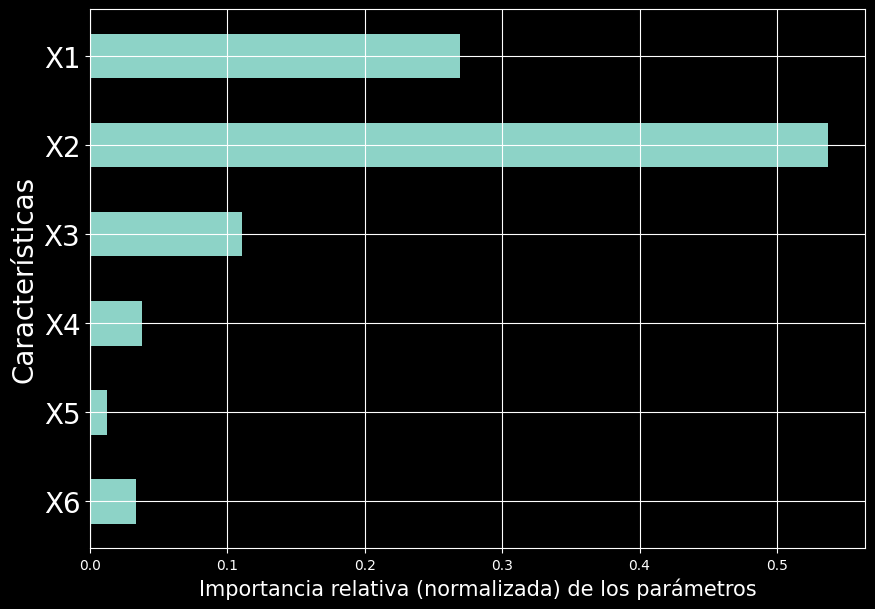

In [41]:
print("Importancia relativa de las características: ", tree_model.feature_importances_)

with plt.style.context('dark_background'):
    plt.figure(figsize=(10, 7))
    plt.grid(True)
    plt.yticks(range(n_features+1, 1, -1), df.columns[:-1], fontsize=20)
    plt.xlabel("Importancia relativa (normalizada) de los parámetros", fontsize=15)
    plt.ylabel("Características", fontsize=20)
    plt.barh(range(n_features+1, 1, -1), width=tree_model.feature_importances_, height=0.5)
plt.show()

Regresión OLS con StatsModels — Reporte completo

In [42]:
import statsmodels.api as sm

# Añadir término constante (intersección)
Xs = sm.add_constant(X)

# Crear y ajustar modelo de Mínimos Cuadrados Ordinarios
stat_model = sm.OLS(y, Xs)
stat_result = stat_model.fit()

# Mostrar tabla completa de resultados
print(stat_result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     628.6
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           5.97e-73
Time:                        23:21:42   Log-Likelihood:                -440.25
No. Observations:                 100   AIC:                             894.5
Df Residuals:                      93   BIC:                             912.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.8565      2.087     -1.848      0.0